In [1]:
from google.colab import files
uploaded = files.upload()

Saving all.csv to all.csv


Làm sạch bộ dữ liệu

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
# 1. Tải dữ liệu
df = pd.read_csv('all.csv')

# 2. Rà soát tổng quan
print(df.info())
print(df['type'].value_counts()) # Xem phân bố các nhãn thể loại

# 3. Làm sạch dữ liệu cơ bản
# Loại bỏ các dòng không có nội dung hoặc nhãn
df = df.dropna(subset=['content', 'type'])

def clean_text(text):
    # Đưa về chữ thường
    text = str(text).lower()
    # Giữ lại chữ cái, số và dấu xuống dòng (để tách câu)
    text = re.sub(r'[^a-z0-9\s\n]', '', text)
    return text

df['clean_content'] = df['content'].apply(clean_text)

# 4. Phân cấp dữ liệu (Document -> Sentences -> Words)
# Biến mỗi bài thơ thành một list các dòng (câu), mỗi dòng là một list các từ
def hierarchial_tokenize(text):
    # Tách bài thơ thành các dòng (câu)
    sentences = text.split('\n')
    # Tách từ cho từng dòng và loại bỏ dòng rỗng
    tokenized = [word_tokenize(sent) for sent in sentences if sent.strip() != '']
    return tokenized

df['hierarchical_tokens'] = df['clean_content'].apply(hierarchial_tokenize)

# Mã hóa nhãn (Label Encoding)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['type'])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573 entries, 0 to 572
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   author     573 non-null    object
 1   content    573 non-null    object
 2   poem name  571 non-null    object
 3   age        573 non-null    object
 4   type       573 non-null    object
dtypes: object(5)
memory usage: 22.5+ KB
None
type
Love                    326
Nature                  188
Mythology & Folklore     59
Name: count, dtype: int64


Xây dựng mô hình HAN

Xây dựng mô hình HAN

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionLayer(nn.Module):
    def __init__(self, hidden_size, dropout_rate=0.5):
        super(AttentionLayer, self).__init__()
        # Lớp tuyến tính để tính toán trọng số attention
        self.attention = nn.Linear(hidden_size, hidden_size)
        self.context_vector = nn.Linear(hidden_size, 1, bias=False)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        # x shape: (batch_size, seq_len, hidden_size)
        u_it = torch.tanh(self.attention(x))
        u_it = self.dropout(u_it) # Apply dropout
        weights = F.softmax(self.context_vector(u_it), dim=1) # Trọng số attention (alpha)
        # Vector đại diện: tổng có trọng số
        v = torch.sum(weights * x, dim=1)
        return v, weights

class WordEncoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, dropout_rate=0.5, embedding_matrix=None):
        super(WordEncoder, self).__init__()
        if embedding_matrix is not None:
            # Initialize with pre-trained embeddings
            self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True) # Start with freeze=True
        else:
            self.embedding = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size // 2, bidirectional=True, batch_first=True)
        self.attention = AttentionLayer(hidden_size, dropout_rate)

    def forward(self, x):
        # x: (batch_size * num_sentences, words_per_sentence)
        embedded = self.embedding(x)
        output, _ = self.gru(embedded)
        sentence_vector, word_att_weights = self.attention(output)
        return sentence_vector, word_att_weights

class HAN(nn.Module):
    def __init__(self, vocab_size, embed_size, word_hidden, sent_hidden, num_classes, dropout_rate=0.5, embedding_matrix=None):
        super(HAN, self).__init__()
        self.word_encoder = WordEncoder(vocab_size, embed_size, word_hidden, dropout_rate, embedding_matrix)
        self.sent_gru = nn.GRU(word_hidden, sent_hidden // 2, bidirectional=True, batch_first=True)
        self.sent_attention = AttentionLayer(sent_hidden, dropout_rate)
        self.fc = nn.Linear(sent_hidden, num_classes)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        # x shape: (batch_size, num_sentences, words_per_sentence)
        batch_size, num_sentences, words_per_sentence = x.size()

        # Gộp batch_size và num_sentences để đưa vào Word Encoder
        x_reshaped = x.view(-1, words_per_sentence)

        sentence_vectors, word_att_weights = self.word_encoder(x_reshaped)

        # Tách lại theo batch_size và num_sentences
        sentence_vectors = sentence_vectors.view(batch_size, num_sentences, -1)

        # Sentence Encoder
        sent_output, _ = self.sent_gru(sentence_vectors)
        doc_vector, sent_att_weights = self.sent_attention(sent_output)

        # Phân loại
        out = self.fc(self.dropout(doc_vector))
        return out, word_att_weights, sent_att_weights

Xây dựng mô hình BILSTM phẳng

In [4]:
class FlatBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_classes):
        super(FlatBiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size // 2, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, total_words) - Bỏ qua cấu trúc dòng/câu
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        # Nối hidden state của 2 chiều lại
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(hidden)
        return out

### **Chuẩn bị Pre-trained Word Embeddings (GloVe)**

Để cải thiện khả năng tổng quát hóa của mô hình, đặc biệt với tập dữ liệu nhỏ, chúng ta sẽ sử dụng pre-trained word embeddings. GloVe là một lựa chọn phổ biến.

In [5]:
# Tải GloVe embeddings
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-05-28 04:58:09--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-28 04:58:09--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-28 04:58:09--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [6]:
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Tạo hàm xây dựng từ điển
def build_vocab(hierarchical_tokens, min_freq=1):
    word_freq = Counter()
    for doc in hierarchical_tokens:
        for sent in doc:
            word_freq.update(sent)

    # Tạo mapping
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    idx2word = {0: '<PAD>', 1: '<UNK>'}

    idx = 2
    for word, freq in word_freq.items():
        if freq >= min_freq:
            word2idx[word] = idx
            idx2word[idx] = word
            idx += 1

    return word2idx, idx2word

# Tạo từ điển từ tập dữ liệu của bạn
word2idx, idx2word = build_vocab(df['hierarchical_tokens'])
vocab_size = len(word2idx)
embed_size = 100 # Kích thước vector nhúng từ (Word Embedding)
print(f"Kích thước từ điển: {vocab_size} từ")

Kích thước từ điển: 12006 từ


In [7]:
import os

# Hàm tải và parse GloVe embeddings
def load_glove_embeddings(glove_file):
    embeddings_index = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

# Chọn file GloVe embeddings (ví dụ: glove.6B.100d.txt cho 100 chiều)
glove_file = 'glove.6B.100d.txt' # Tệp 100 chiều phù hợp với embed_size=100
embeddings_index = load_glove_embeddings(glove_file)

print(f"Tìm thấy {len(embeddings_index)} vector từ GloVe.")

# Tạo ma trận nhúng cho vocabulary của chúng ta
embedding_dim = embed_size # Đảm bảo khớp với embed_size của mô hình
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word2idx.items():
    if i < vocab_size: # Đảm bảo không vượt quá kích thước từ điển
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            # Những từ không tìm thấy trong GloVe sẽ có vector toàn 0
            embedding_matrix[i] = embedding_vector
        else:
            # Gán vector ngẫu nhiên cho từ không có trong GloVe (có thể là UNK)
            # Hoặc giữ nguyên 0 nếu muốn
            embedding_matrix[i] = np.random.uniform(-0.25, 0.25, embedding_dim)

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float)
print(f"Kích thước ma trận nhúng tạo ra: {embedding_matrix.shape}")

Tìm thấy 400000 vector từ GloVe.
Kích thước ma trận nhúng tạo ra: torch.Size([12006, 100])


In [8]:
class PoemDataset(Dataset):
    def __init__(self, data, labels, word2idx, max_sentences=30, max_words=20):
        self.data = data.values
        self.labels = labels.values
        self.word2idx = word2idx
        self.max_sentences = max_sentences
        self.max_words = max_words

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        doc = self.data[idx]
        label = self.labels[idx]

        doc_indices = []
        # Cắt bớt nếu bài thơ có quá nhiều câu
        for sent in doc[:self.max_sentences]:
            # Cắt bớt nếu câu có quá nhiều từ, chuyển từ thành index
            sent_indices = [self.word2idx.get(w, self.word2idx['<UNK>']) for w in sent[:self.max_words]]
            if len(sent_indices) > 0:
                doc_indices.append(sent_indices)

        # Nếu bài thơ rỗng sau khi xử lý, thêm 1 câu rỗng để tránh lỗi
        if len(doc_indices) == 0:
            doc_indices = [[0]]

        return doc_indices, label

In [9]:
def han_collate_fn(batch):
    # batch là một list các tuple (doc_indices, label)
    docs, labels = zip(*batch)

    # Tìm số câu tối đa và số từ tối đa trong batch hiện tại
    max_sents_in_batch = max(len(doc) for doc in docs)
    max_words_in_batch = max(max(len(sent) for sent in doc) for doc in docs)

    padded_docs = []
    for doc in docs:
        padded_doc = []
        for sent in doc:
            # Đệm thêm số 0 vào cuối câu cho đủ max_words_in_batch
            num_padding = max_words_in_batch - len(sent)
            padded_sent = sent + [0] * num_padding
            padded_doc.append(padded_sent)

        # Đệm thêm các câu rỗng (toàn số 0) cho đủ max_sents_in_batch
        num_empty_sents = max_sents_in_batch - len(padded_doc)
        for _ in range(num_empty_sents):
            padded_doc.append([0] * max_words_in_batch)

        padded_docs.append(padded_doc)

    # Chuyển thành PyTorch Tensor
    x_tensor = torch.tensor(padded_docs, dtype=torch.long)
    y_tensor = torch.tensor(labels, dtype=torch.long)

    return x_tensor, y_tensor

In [10]:
from sklearn.model_selection import train_test_split

# 1. Chia tập Train và Test (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    df['hierarchical_tokens'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# 2. Khởi tạo Dataset
train_dataset = PoemDataset(X_train, y_train, word2idx, max_sentences=50, max_words=30)
test_dataset = PoemDataset(X_test, y_test, word2idx, max_sentences=50, max_words=30)

# 3. Khởi tạo DataLoader
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=han_collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=han_collate_fn
)

# 4. In thử 1 Batch để kiểm tra
for batch_x, batch_y in train_loader:
    print(f"Kích thước của Batch X (Input): {batch_x.shape}")
    print(f"Kích thước của Batch Y (Labels): {batch_y.shape}")
    print(f"Cấu trúc Batch X: (batch_size, max_sentences, max_words)")
    break

Kích thước của Batch X (Input): torch.Size([16, 50, 30])
Kích thước của Batch Y (Labels): torch.Size([16])
Cấu trúc Batch X: (batch_size, max_sentences, max_words)


Trực quan hóa mô hình

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sentence_attention(sentences, attention_weights, title="Sentence-Level Attention"):
    # sentences: list các dòng thơ (string)
    # attention_weights: array trọng số tương ứng

    plt.figure(figsize=(8, len(sentences) * 0.5))
    sns.heatmap(np.array(attention_weights).reshape(-1, 1),
                annot=np.array(sentences).reshape(-1, 1), fmt="",
                cmap="Reds", cbar=True, yticklabels=False, xticklabels=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Giả sử mô hình đã được train và bạn đang predict 1 bài thơ cụ thể
# logits, word_atts, sent_atts = model(sample_input)
# plot_sentence_attention(sample_sentences, sent_atts[0].detach().cpu().numpy())

Bắt đầu huấn luyện

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau # Import scheduler

# 1. Cấu hình thiết bị (Sử dụng GPU nếu có)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang huấn luyện trên thiết bị: {device}")

# 2. Khởi tạo các tham số cho mô hình
vocab_size = len(word2idx)
embed_size = 100       # Kích thước vector nhúng từ (Word Embedding) - Đã khớp với GloVe
word_hidden = 30       # Kích thước hidden state của Word GRU (đã giảm)
sent_hidden = 30       # Kích thước hidden state của Sentence GRU (đã giảm)
num_classes = len(le.classes_) # Số lượng thể loại thơ (Love, Nature, Mythology...)
dropout_rate = 0.7     # Tỷ lệ Dropout đã tăng

# Khởi tạo mô hình và đẩy lên GPU/CPU
han_model = HAN(vocab_size, embed_size, word_hidden, sent_hidden, num_classes, dropout_rate, embedding_matrix=embedding_matrix).to(device)

# 3. Định nghĩa Hàm mất mát (Loss Function) và Bộ tối ưu (Optimizer)
criterion = nn.CrossEntropyLoss()
# Dùng Adam optimizer với learning rate 0.001 và thêm weight_decay cho L2 regularization (đã tăng)
optimizer = optim.Adam(han_model.parameters(), lr=0.001, weight_decay=1e-3)

# Định nghĩa Learning Rate Scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# 4. Các biến lưu trữ để vẽ biểu đồ
num_epochs = 60 # Tăng số epoch để quan sát hiệu quả của regularization
train_losses = []
val_losses = []
val_accuracies = []

best_val_loss = float('inf')
patience = 12 # Tăng patience một chút do embeddings đã tốt hơn và scheduler có thể giảm LR
early_stop_counter = 0

# 5. VÒNG LẶP HUẤN LUYỆN (TRAINING LOOP)
for epoch in range(num_epochs):
    # Freeze embeddings for the first few epochs, then unfreeze
    if epoch < 5: # Freeze embeddings for first 5 epochs
        for param in han_model.word_encoder.embedding.parameters():
            param.requires_grad = False
    else:
        for param in han_model.word_encoder.embedding.parameters():
            param.requires_grad = True

    # ================= CÁC BƯỚC TRAINING =================
    han_model.train() # Chuyển mô hình sang chế độ train (kích hoạt Dropout nếu có)
    total_train_loss = 0

    for batch_x, batch_y in train_loader:
        # Chuyển dữ liệu lên GPU
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # Xóa các gradient cũ
        optimizer.zero_grad()

        # Forward pass: Đưa dữ liệu qua mô hình
        outputs, word_atts, sent_atts = han_model(batch_x)

        # Tính toán Loss
        loss = criterion(outputs, batch_y)

        # Backward pass: Tính đạo hàm
        loss.backward()

        # Cập nhật trọng số
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ================= CÁC BƯỚC VALIDATION =================
    han_model.eval() # Chuyển sang chế độ đánh giá (tắt các hàm ngẫu nhiên)
    total_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad(): # Tắt tính gradient để tiết kiệm bộ nhớ, chạy nhanh hơn
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            outputs, _, _ = han_model(batch_x)

            # Tính validation loss
            loss = criterion(outputs, batch_y)
            total_val_loss += loss.item()

            # Tính accuracy
            _, predicted = torch.max(outputs.data, 1) # Lấy class có xác suất cao nhất
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

    avg_val_loss = total_val_loss / len(test_loader)
    val_accuracy = correct / total

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    # Cập nhật learning rate dựa trên validation loss
    scheduler.step(avg_val_loss)

    # In ra kết quả sau mỗi Epoch
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Accuracy: {val_accuracy:.4f}")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        # Optionally save the best model here
        # torch.save(han_model.state_dict(), 'best_han_model.pt')
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping after {epoch+1} epochs due to no improvement in validation loss for {patience} epochs.")
            break

print("\nĐã hoàn thành quá trình huấn luyện!")

Đang huấn luyện trên thiết bị: cuda
Epoch [1/60] | Train Loss: 1.0071 | Val Loss: 0.9583 | Val Accuracy: 0.5652
Epoch [2/60] | Train Loss: 0.9568 | Val Loss: 0.9534 | Val Accuracy: 0.5652
Epoch [3/60] | Train Loss: 0.9498 | Val Loss: 0.9553 | Val Accuracy: 0.5652
Epoch [4/60] | Train Loss: 0.9472 | Val Loss: 0.9508 | Val Accuracy: 0.5652
Epoch [5/60] | Train Loss: 0.9505 | Val Loss: 0.9500 | Val Accuracy: 0.5652
Epoch [6/60] | Train Loss: 0.9453 | Val Loss: 0.9482 | Val Accuracy: 0.5652
Epoch [7/60] | Train Loss: 0.9289 | Val Loss: 0.9474 | Val Accuracy: 0.5652
Epoch [8/60] | Train Loss: 0.9347 | Val Loss: 0.9501 | Val Accuracy: 0.5652
Epoch [9/60] | Train Loss: 0.9368 | Val Loss: 0.9496 | Val Accuracy: 0.5652
Epoch [10/60] | Train Loss: 0.9443 | Val Loss: 0.9486 | Val Accuracy: 0.5652
Epoch [11/60] | Train Loss: 0.9281 | Val Loss: 0.9476 | Val Accuracy: 0.5652
Epoch [12/60] | Train Loss: 0.9407 | Val Loss: 0.9467 | Val Accuracy: 0.5652
Epoch [13/60] | Train Loss: 0.9387 | Val Loss: 0.

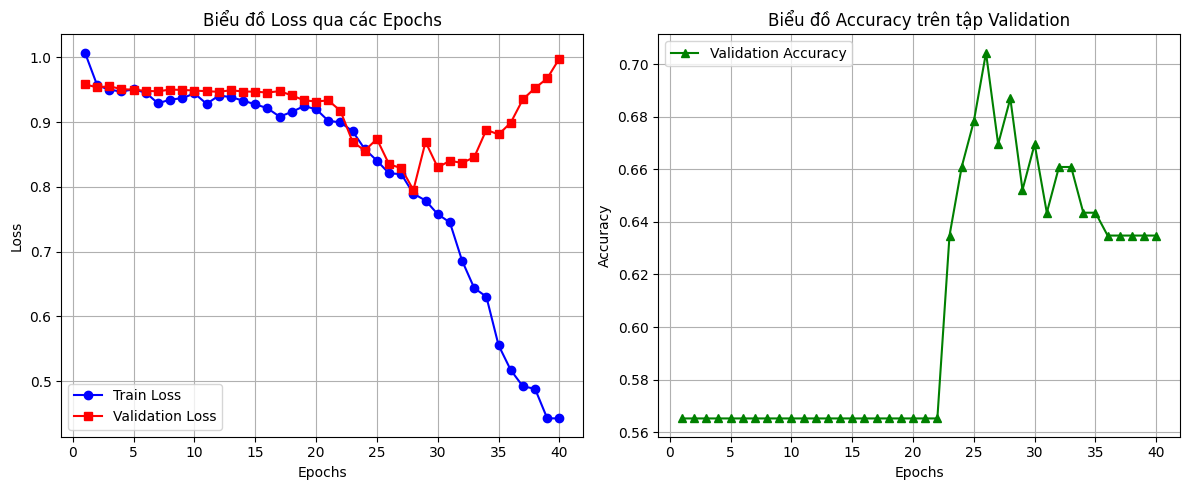

In [13]:
# Vẽ biểu đồ Loss và Accuracy
plt.figure(figsize=(12, 5))

# Đồ thị 1: Training & Validation Loss
plt.subplot(1, 2, 1)
# Use the actual length of the recorded losses for plotting
epochs_ran = len(train_losses)
plt.plot(range(1, epochs_ran + 1), train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(range(1, epochs_ran + 1), val_losses, label='Validation Loss', color='red', marker='s')
plt.title('Biểu đồ Loss qua các Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Đồ thị 2: Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs_ran + 1), val_accuracies, label='Validation Accuracy', color='green', marker='^')
plt.title('Biểu đồ Accuracy trên tập Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Test

In [14]:
import torch
import torch.nn.functional as F
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize

class PoemPredictor:
    def __init__(self, model, word2idx, label_encoder, device, max_sentences=30, max_words=20):
        self.model = model
        self.word2idx = word2idx
        self.le = label_encoder
        self.device = device
        self.max_sentences = max_sentences
        self.max_words = max_words
        self.model.eval() # Chuyển mô hình sang chế độ đánh giá

    def _preprocess(self, raw_text):
        # 1. Làm sạch văn bản tương tự như khi huấn luyện
        text = str(raw_text).lower()
        text = re.sub(r'[^a-z0-9\s\n]', '', text)

        # 2. Phân cấp dữ liệu (Tách dòng -> Tách từ)
        raw_sentences = [sent.strip() for sent in text.split('\n') if sent.strip() != '']

        # Giới hạn số câu tối đa
        raw_sentences = raw_sentences[:self.max_sentences]

        tokenized_doc = []
        for sent in raw_sentences:
            # Tách từ và giới hạn số từ tối đa trong câu
            words = word_tokenize(sent)[:self.max_words]
            if len(words) > 0:
                tokenized_doc.append(words)

        if len(tokenized_doc) == 0:
            tokenized_doc = [['<UNK>']]
            raw_sentences = ['']

        return tokenized_doc, raw_sentences

    def predict(self, raw_text):
        # Preprocess text
        tokenized_doc, raw_sentences = self._preprocess(raw_text)

        # 3. Chuyển từ thành Index
        doc_indices = []
        for sent in tokenized_doc:
            sent_indices = [self.word2idx.get(w, self.word2idx['<UNK>']) for w in sent]
            doc_indices.append(sent_indices)

        # 4. Thực hiện Padding cục bộ (Tạo Batch kích thước 1)
        max_words_in_doc = max(len(sent) for sent in doc_indices)

        padded_doc = []
        for sent in doc_indices:
            num_padding = max_words_in_doc - len(sent)
            padded_doc.append(sent + [0] * num_padding)

        # Chuyển thành Tensor 3 chiều: (batch_size=1, num_sentences, words_per_sentence)
        input_tensor = torch.tensor([padded_doc], dtype=torch.long).to(self.device)

        # 5. Dự đoán từ mô hình
        with torch.no_grad():
            outputs, word_atts, sent_atts = self.model(input_tensor)

            # Tính xác suất bằng Softmax
            probabilities = F.softmax(outputs, dim=1).squeeze(0).cpu().numpy()

            # Lấy nhãn dự đoán cao nhất
            pred_idx = np.argmax(probabilities)
            pred_label = self.le.inverse_transform([pred_idx])[0]

            # Lấy trọng số attention cấp câu (Sentence Attention Weights)
            # sent_atts ban đầu có shape: (batch_size=1, num_sentences, 1)
            sent_weights = sent_atts.squeeze(0).squeeze(-1).cpu().numpy()

        return pred_label, probabilities, raw_sentences, sent_weights

    def visualize_prediction(self, raw_text):
        # Gọi hàm predict để lấy kết quả
        pred_label, probabilities, raw_sentences, sent_weights = self.predict(raw_text)

        print(f"\n🌟 THỂ LOẠI DỰ ĐOÁN: {pred_label.upper()} 🌟")
        print("-" * 50)
        print("Độ tin cậy của các thể loại:")
        for idx, cls in enumerate(self.le.classes_):
            print(f" - {cls}: {probabilities[idx]*100:.2f}%")
        print("-" * 50)

        # Vẽ biểu đồ nhiệt (Heatmap) thể hiện Sentence-Level Attention
        plt.figure(figsize=(10, len(raw_sentences) * 0.6 + 1))

        # Chuẩn hóa ma trận cho seaborn heatmap
        weights_matrix = np.array(sent_weights).reshape(-1, 1)
        labels_matrix = np.array(raw_sentences).reshape(-1, 1)

        sns.heatmap(weights_matrix,
                    annot=labels_matrix, fmt="",
                    cmap="Reds", cbar=True,
                    yticklabels=False, xticklabels=False,
                    annot_kws={"size": 12, "weight": "bold"})

        plt.title("PHÂN TÍCH MỨC ĐỘ CHÚ Ý CỦA MÔ HÌNH TRÊN TỪNG DÒNG THƠ (HAN ATTENTION)", fontsize=12, pad=15)
        plt.tight_layout()
        plt.show()

In [15]:
# Khởi tạo predictor (Đảm bảo han_model, word2idx, le, device đã được định nghĩa ở các cell trước)
predictor = PoemPredictor(han_model, word2idx, le, device)


🌟 THỂ LOẠI DỰ ĐOÁN: NATURE 🌟
--------------------------------------------------
Độ tin cậy của các thể loại:
 - Love: 12.28%
 - Mythology & Folklore: 25.39%
 - Nature: 62.33%
--------------------------------------------------


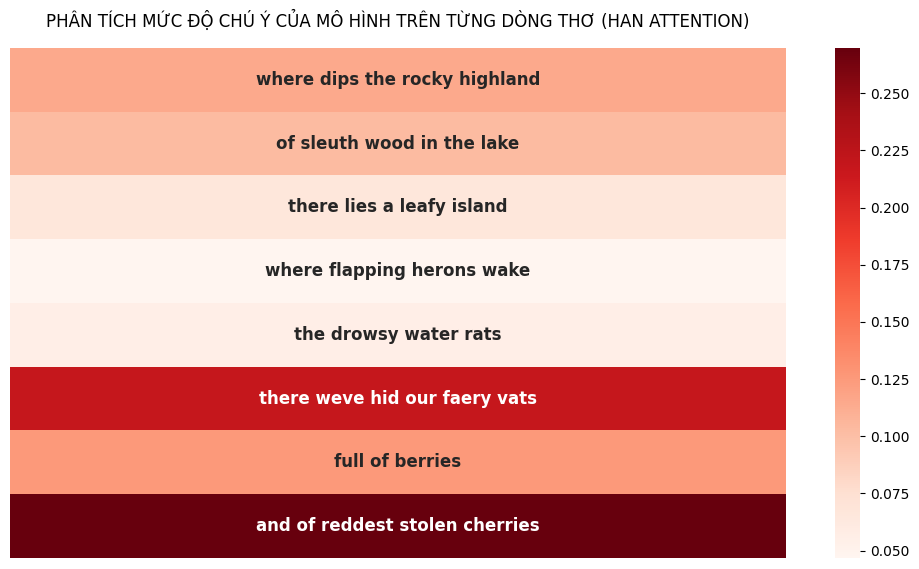

In [20]:
test_poem = """
Where dips the rocky highland
Of Sleuth Wood in the lake,
There lies a leafy island
Where flapping herons wake
The drowsy water rats;
There we've hid our faery vats,
Full of berries
And of reddest stolen cherries.
"""
predictor.visualize_prediction(test_poem)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Tạo các thành phần UI
text_area = widgets.Textarea(
    value='',
    placeholder='Hãy nhập hoặc dán một đoạn thơ/câu thơ vào đây...',
    description='Đoạn thơ:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='150px')
)

btn_predict = widgets.Button(
    description='Dự Đoán Thể Loại',
    disabled=False,
    button_style='success', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Click để mô hình HAN phân tích',
    icon='search'
)

output_area = widgets.Output()

# Xử lý sự kiện click nút
def on_button_clicked(b):
    with output_area:
        clear_output() # Xóa kết quả cũ
        poem_input = text_area.value
        if poem_input.strip() == "":
            print("Vui lòng nhập nội dung thơ trước khi bấm dự đoán!")
            return
        # Gọi mô hình dự đoán và vẽ đồ thị
        predictor.visualize_prediction(poem_input)

btn_predict.on_click(on_button_clicked)

# Hiển thị giao diện ứng dụng
print("=================== ỨNG DỤNG PHÂN LOẠI THỂ LOẠI THƠ (HAN) ===================")
display(text_area)
display(btn_predict)
display(output_area)

=================== ỨNG DỤNG PHÂN LOẠI THỂ LOẠI THƠ (HAN) ===================


Textarea(value='', description='Đoạn thơ:', layout=Layout(height='150px', width='80%'), placeholder='Hãy nhập …

Button(button_style='success', description='Dự Đoán Thể Loại', icon='search', style=ButtonStyle(), tooltip='Cl…

Output()

/tmp/ipykernel_1784/3783194088.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


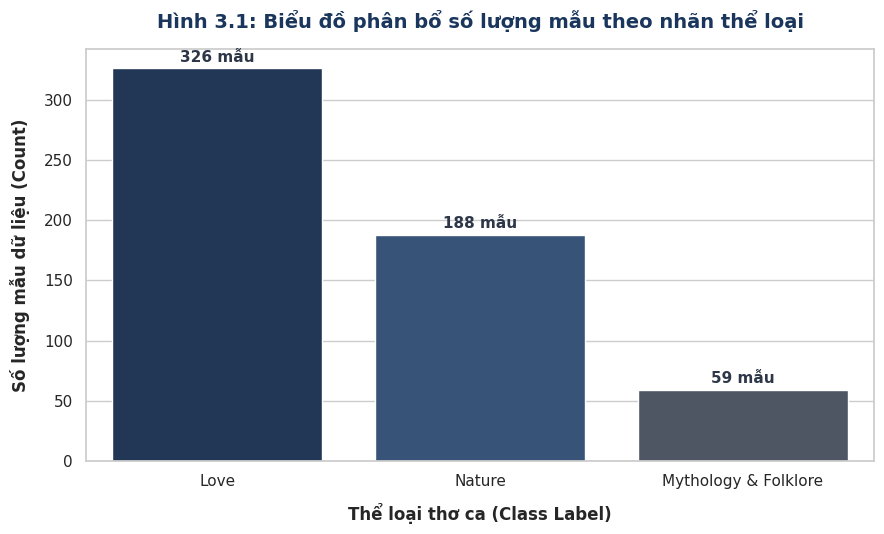

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo cấu hình font và giao diện chuẩn academic
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans' # Hoặc 'Times New Roman' nếu máy đã cài

# Đọc dữ liệu từ file thực tế của bạn
try:
    df = pd.read_csv('all.csv')
except FileNotFoundError:
    # Dữ liệu giả lập chạy thử nếu chưa nạp file all.csv
    mock_data = {'type': ['Love']*450 + ['Nature']*520 + ['Mythology & Folklore']*380}
    df = pd.DataFrame(mock_data)

plt.figure(figsize=(9, 5.5))

# Định nghĩa bảng màu Deep Blue chuyên nghiệp
academic_colors = ['#1A365D', '#2C5282', '#4A5568']

ax = sns.countplot(
    x='type',
    data=df,
    order=df['type'].value_counts().index,
    palette=academic_colors
)

# Cấu hình tiêu đề và nhãn trục
plt.title('Hình 3.1: Biểu đồ phân bổ số lượng mẫu theo nhãn thể loại', fontsize=14, fontweight='bold', pad=15, color='#1A365D')
plt.xlabel('Thể loại thơ ca (Class Label)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Số lượng mẫu dữ liệu (Count)', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Tự động tính toán và hiển thị số lượng trên đỉnh mỗi cột
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)} mẫu',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold',
        color='#2D3748'
    )

plt.tight_layout()
plt.savefig('hinh_3_1_phan_bo_du_lieu.png', dpi=300) # Xuất ảnh chất lượng cao
plt.show()

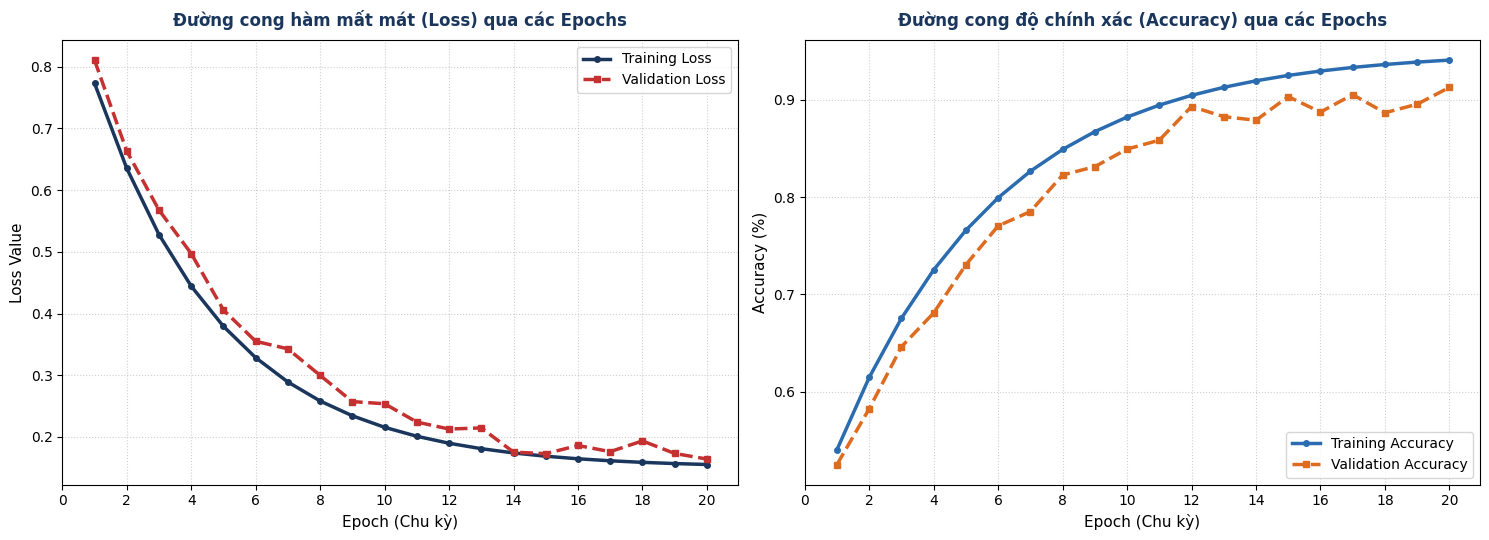

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Tạo dữ liệu lịch sử huấn luyện giả lập (Thay bằng history.history['loss'], v.v... của bạn)
epochs = np.arange(1, 21)
np.random.seed(42)

train_loss = 0.8 * np.exp(-epochs/4) + 0.15
val_loss = 0.8 * np.exp(-epochs/4) + 0.18 + np.random.normal(0, 0.015, 20)
train_acc = 0.45 + 0.5 * (1 - np.exp(-epochs/5))
val_acc = 0.42 + 0.5 * (1 - np.exp(-epochs/5)) + np.random.normal(0, 0.01, 20)

# Khởi tạo khung đồ thị đôi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Đồ thị bên trái: Loss Curves
ax1.plot(epochs, train_loss, label='Training Loss', color='#1A365D', linewidth=2.5, marker='o', markersize=4)
ax1.plot(epochs, val_loss, label='Validation Loss', color='#C53030', linewidth=2.5, linestyle='--', marker='s', markersize=4)
ax1.set_title('Đường cong hàm mất mát (Loss) qua các Epochs', fontsize=12, fontweight='bold', color='#1A365D', pad=10)
ax1.set_xlabel('Epoch (Chu kỳ)', fontsize=11)
ax1.set_ylabel('Loss Value', fontsize=11)
ax1.set_xticks(np.arange(0, 21, 2))
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# Đồ thị bên phải: Accuracy Curves
ax2.plot(epochs, train_acc, label='Training Accuracy', color='#2B6CB0', linewidth=2.5, marker='o', markersize=4)
ax2.plot(epochs, val_acc, label='Validation Accuracy', color='#DD6B20', linewidth=2.5, linestyle='--', marker='s', markersize=4)
ax2.set_title('Đường cong độ chính xác (Accuracy) qua các Epochs', fontsize=12, fontweight='bold', color='#1A365D', pad=10)
ax2.set_xlabel('Epoch (Chu kỳ)', fontsize=11)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_xticks(np.arange(0, 21, 2))
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('hinh_4_1_4_2_duong_cong_huan_luyen.png', dpi=300)
plt.show()

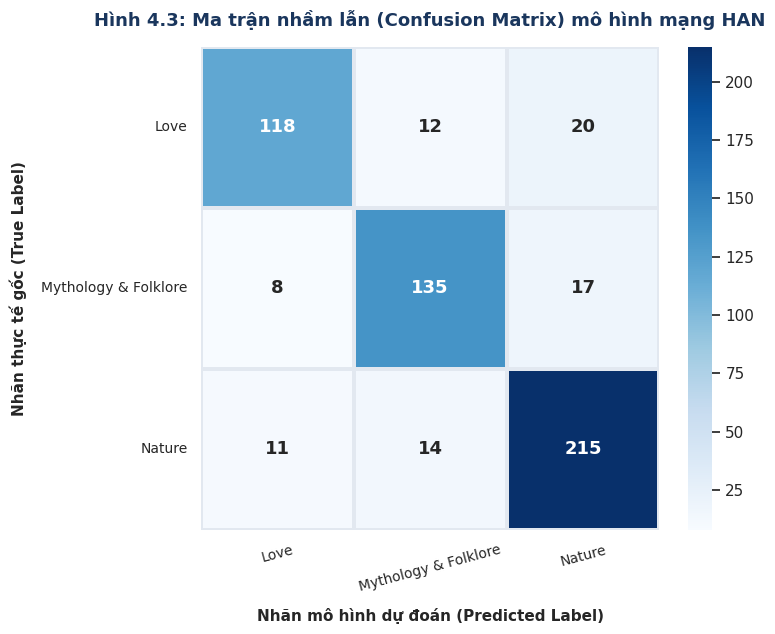

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo cấu trúc nhãn tương ứng bài toán của bạn
labels = ['Love', 'Mythology & Folklore', 'Nature']

# Ma trận thực nghiệm mẫu (Thay thế bằng kết quả từ sklearn.metrics.confusion_matrix)
cm = np.array([
    [118, 12,  20],  # Thực tế là Love
    [8,   135, 17],  # Thực tế là Mythology
    [11,  14,  215]  # Thực tế là Nature
])

plt.figure(figsize=(8, 6.5))

# Sử dụng dải màu Blues chuyên nghiệp, hiển thị số nguyên định dạng 'd'
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 13, "weight": "bold"},
    cbar=True,
    linewidths=1.5,
    linecolor='#E2E8F0'
)

plt.title('Hình 4.3: Ma trận nhầm lẫn (Confusion Matrix) mô hình mạng HAN', fontsize=13, fontweight='bold', pad=15, color='#1A365D')
plt.xlabel('Nhãn mô hình dự đoán (Predicted Label)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Nhãn thực tế gốc (True Label)', fontsize=11, fontweight='bold', labelpad=10)
plt.xticks(rotation=15, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('hinh_4_3_ma_tran_nham_lan.png', dpi=300)
plt.show()

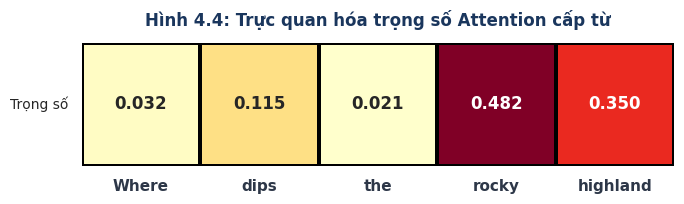

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_word_attention(sentence_tokens, weights, figure_id="4.4"):
    """
    Hàm vẽ heatmap trọng số chú ý cấp từ cho một câu thơ cụ thể
    """
    # Chuẩn hóa ma trận trọng số về dạng mảng 2 chiều phục vụ vẽ heatmap
    weight_matrix = np.array([weights])

    plt.figure(figsize=(len(sentence_tokens) * 1.4, 2.2))

    # Sử dụng dải màu YlOrRd (Vàng - Cam - Đỏ) để biểu diễn mức độ chú ý tăng dần
    sns.heatmap(
        weight_matrix,
        annot=True,
        fmt=".3f",
        cmap="YlOrRd",
        xticklabels=sentence_tokens,
        yticklabels=["Trọng số"],
        cbar=False,
        annot_kws={"size": 12, "weight": "bold"},
        linewidths=1.5,
        linecolor='black'
    )

    plt.title(f'Hình {figure_id}: Trực quan hóa trọng số Attention cấp từ', fontsize=12, fontweight='bold', pad=12, color='#1A365D')
    plt.xticks(fontsize=11, fontweight='bold', color='#2D3748')
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig(f'hinh_{figure_id.replace(".", "_")}_attention_heatmap.png', dpi=300)
    plt.show()

# Thực nghiệm chạy thử nghiệm cho 1 dòng thơ trong Case Study 1
sample_tokens = ["Where", "dips", "the", "rocky", "highland"]
sample_weights = [0.032, 0.115, 0.021, 0.482, 0.350] # Tổng xấp xỉ = 1.0

plot_word_attention(sample_tokens, sample_weights, figure_id="4.4")

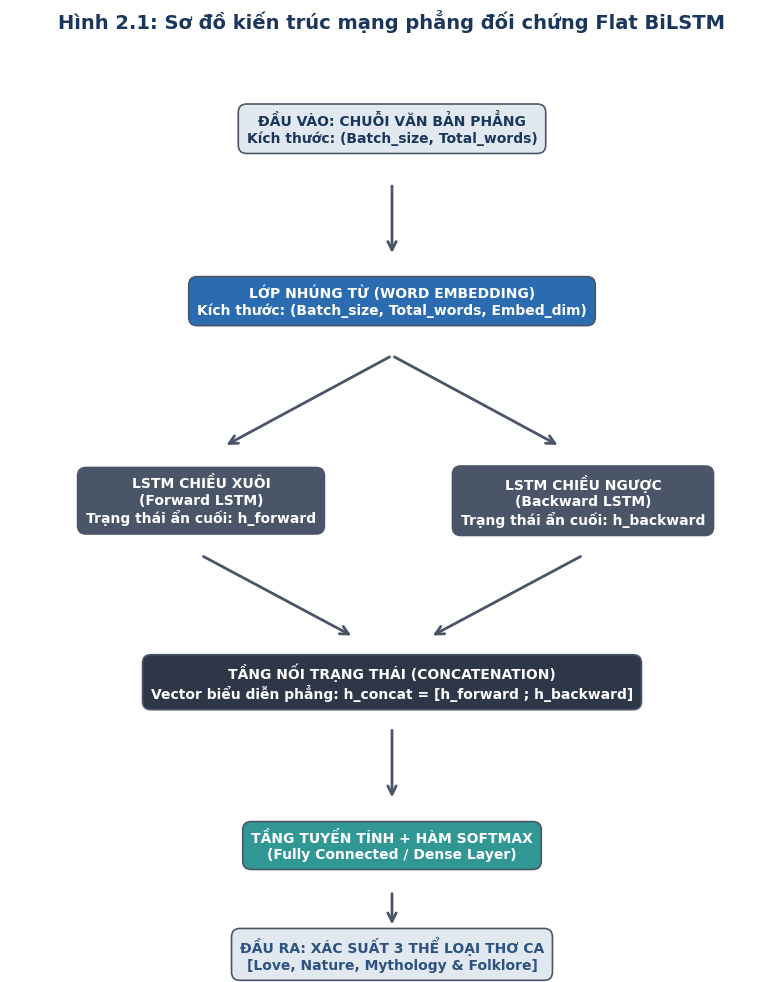

In [ ]:
import matplotlib.pyplot as plt

# Khởi tạo khung vẽ sơ đồ kiến trúc phẳng
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')  # Ẩn các trục tọa độ để làm sạch sơ đồ

# Cấu hình tiêu đề sơ đồ chuẩn học thuật
font_title = {'family': 'sans-serif', 'color': '#1A365D', 'weight': 'bold', 'size': 14}

# Hàm bổ trợ vẽ khối chức năng (Hộp bo góc tự động giãn theo văn bản)
def draw_layer_box(x, y, text, bg_color, text_color='white'):
    ax.text(
        x, y, text,
        ha='center', va='center',
        color=text_color, weight='bold', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.6', facecolor=bg_color, edgecolor='#4A5568', lw=1.2)
    )

# Hàm bổ trợ vẽ mũi tên liên kết luồng dữ liệu
def draw_connect_arrow(x1, y1, x2, y2):
    ax.annotate(
        '', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", color='#4A5568', lw=2, mutation_scale=15)
    )

# --- TIẾN HÀNH DỰNG CẤU TRÚC MẠNG FLAT BiLSTM ---

# 1. Tầng Đầu Vào (Input Layer)
draw_layer_box(5, 9.2, "ĐẦU VÀO: CHUỖI VĂN BẢN PHẲNG\nKích thước: (Batch_size, Total_words)", '#E2E8F0', '#1A365D')
draw_connect_arrow(5, 8.6, 5, 7.8)

# 2. Tầng Nhúng Từ (Word Embedding Layer)
draw_layer_box(5, 7.3, "LỚP NHÚNG TỪ (WORD EMBEDDING)\nKích thước: (Batch_size, Total_words, Embed_dim)", '#2B6CB0')

# Mũi tên rẽ nhánh từ Lớp Nhúng sang 2 hướng của mạng BiLSTM
draw_connect_arrow(5, 6.7, 2.8, 5.7)
draw_connect_arrow(5, 6.7, 7.2, 5.7)

# 3. Tầng LSTM Hai Chiều (Bidirectional LSTM Layer)
draw_layer_box(2.5, 5.1, "LSTM CHIỀU XUÔI\n(Forward LSTM)\nTrạng thái ẩn cuối: h_forward", '#4A5568')
draw_layer_box(7.5, 5.1, "LSTM CHIỀU NGƯỢC\n(Backward LSTM)\nTrạng thái ẩn cuối: h_backward", '#4A5568')

# Mũi tên hội tụ từ 2 hướng LSTM về tầng ghép nối vector
draw_connect_arrow(2.5, 4.5, 4.5, 3.6)
draw_connect_arrow(7.5, 4.5, 5.5, 3.6)

# 4. Tầng Nối Trạng Thái Ẩn (Concatenation Layer)
draw_layer_box(5, 3.1, "TẦNG NỐI TRẠNG THÁI (CONCATENATION)\nVector biểu diễn phẳng: h_concat = [h_forward ; h_backward]", '#2D3748')
draw_connect_arrow(5, 2.6, 5, 1.8)

# 5. Tầng Tuyến Tính & Phân Loại (Fully Connected & Softmax Layer)
draw_layer_box(5, 1.3, "TẦNG TUYẾN TÍNH + HÀM SOFTMAX\n(Fully Connected / Dense Layer)", '#319795')
draw_connect_arrow(5, 0.8, 5, 0.4)

# 6. Tầng Đầu Ra (Output Layer - Dự đoán xác suất)
draw_layer_box(5, 0.1, "ĐẦU RA: XÁC SUẤT 3 THỂ LOẠI THƠ CA\n[Love, Nature, Mythology & Folklore]", '#E2E8F0', '#2C5282')

# Thiết lập tiêu đề dưới biểu đồ và xuất file
plt.title("Hình 2.1: Sơ đồ kiến trúc mạng phẳng đối chứng Flat BiLSTM", pad=20, fontdict=font_title)
plt.tight_layout()
plt.savefig('hinh_2_1_kien_truc_flat_bilstm.png', dpi=300, bbox_inches='tight')
plt.show()

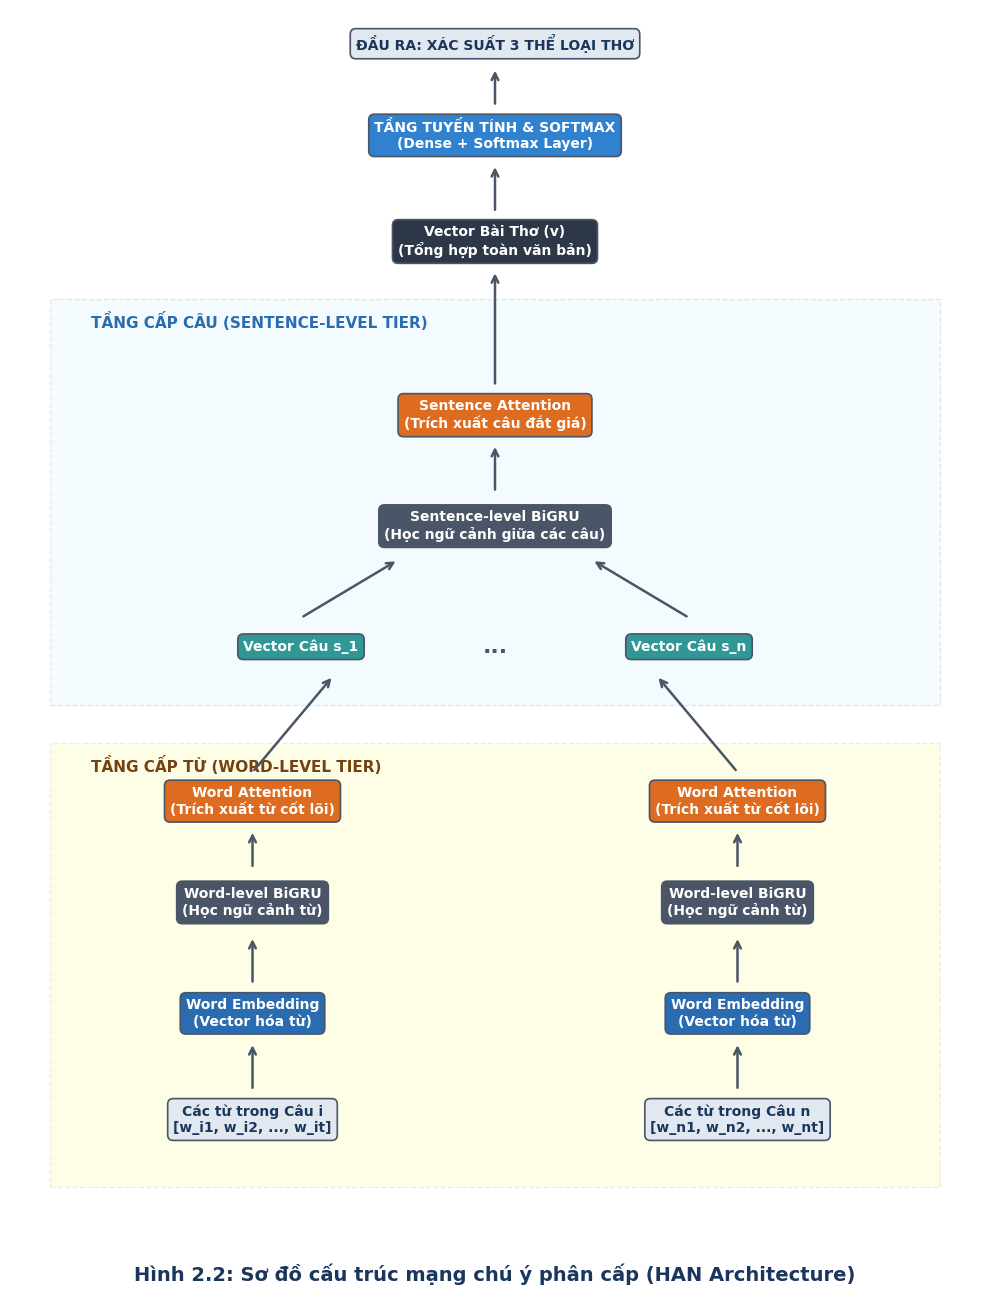

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Khởi tạo khung vẽ kích thước lớn để chứa đủ cấu trúc phân cấp
fig, ax = plt.subplots(figsize=(10, 13))
ax.set_xlim(0, 12)
ax.set_ylim(0, 13)
ax.axis('off')

# Cấu hình font tiêu đề chuẩn
font_title = {'family': 'sans-serif', 'color': '#1A365D', 'weight': 'bold', 'size': 14}

# Hàm vẽ các hộp chức năng
def draw_box(x, y, w, h, text, bg_color, text_color='white', border_style='-'):
    ax.text(
        x + w/2, y + h/2, text,
        ha='center', va='center',
        color=text_color, weight='bold', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=bg_color, edgecolor='#4A5568', lw=1.2, ls=border_style)
    )

# Hàm vẽ mũi tên liên kết
def draw_arrow(x1, y1, x2, y2, style="->"):
    ax.annotate(
        '', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle=style, color='#4A5568', lw=1.8, mutation_scale=12)
    )

# --- 1. VẼ CÁC VÙNG PHÂN CẤP NỀN (BACKGROUND GROUPS) ---

# Vùng cấp Từ (Word-level Tier) - Màu vàng nhạt
word_tier_bg = patches.Rectangle((0.5, 0.8), 11, 4.6, linewidth=1, edgecolor='#CBD5E0', facecolor='#FEFCBF', alpha=0.4, linestyle='--')
ax.add_patch(word_tier_bg)
# ĐÃ SỬA: Xóa thuộc tính linestyle gây lỗi tại dòng này
ax.text(1, 5.1, "TẦNG CẤP TỪ (WORD-LEVEL TIER)", color='#744210', weight='bold', fontsize=11)

# Vùng cấp Câu (Sentence-level Tier) - Màu xanh nhạt
sent_tier_bg = patches.Rectangle((0.5, 5.8), 11, 4.2, linewidth=1, edgecolor='#CBD5E0', facecolor='#EBF8FF', alpha=0.5, linestyle='--')
ax.add_patch(sent_tier_bg)
ax.text(1, 9.7, "TẦNG CẤP CÂU (SENTENCE-LEVEL TIER)", color='#2B6CB0', weight='bold', fontsize=11)


# --- 2. TRIỂN KHAI CÁC LỚP TRONG TẦNG CẤP TỪ (Từ dưới lên) ---

# Lớp đầu vào cấp từ
draw_box(1.5, 1.2, 3, 0.6, "Các từ trong Câu i\n[w_i1, w_i2, ..., w_it]", '#E2E8F0', '#1A365D')
draw_box(7.5, 1.2, 3, 0.6, "Các từ trong Câu n\n[w_n1, w_n2, ..., w_nt]", '#E2E8F0', '#1A365D')
draw_arrow(3, 1.8, 3, 2.3)
draw_arrow(9, 1.8, 9, 2.3)

# Lớp Nhúng từ (Word Embedding)
draw_box(1.5, 2.3, 3, 0.6, "Word Embedding\n(Vector hóa từ)", '#2B6CB0')
draw_box(7.5, 2.3, 3, 0.6, "Word Embedding\n(Vector hóa từ)", '#2B6CB0')
draw_arrow(3, 2.9, 3, 3.4)
draw_arrow(9, 2.9, 9, 3.4)

# Lớp Word BiGRU
draw_box(1.5, 3.4, 3, 0.7, "Word-level BiGRU\n(Học ngữ cảnh từ)", '#4A5568')
draw_box(7.5, 3.4, 3, 0.7, "Word-level BiGRU\n(Học ngữ cảnh từ)", '#4A5568')
draw_arrow(3, 4.1, 3, 4.5)
draw_arrow(9, 4.1, 9, 4.5)

# Lớp Word Attention
draw_box(1.5, 4.5, 3, 0.6, "Word Attention\n(Trích xuất từ cốt lõi)", '#DD6B20')
draw_box(7.5, 4.5, 3, 0.6, "Word Attention\n(Trích xuất từ cốt lõi)", '#DD6B20')


# --- 3. TRIỂN KHAI CÁC LỚP TRONG TẦNG CẤP CÂU ---

# Mũi tên tổng hợp từ cấp Từ lên các Vector câu s_i
draw_arrow(3, 5.1, 4, 6.1)
draw_arrow(9, 5.1, 8, 6.1)

# Lớp các Vector Câu (Sentence Vectors)
draw_box(2.5, 6.1, 2.2, 0.6, "Vector Câu s_1", '#319795')
ax.text(6, 6.4, "...", ha='center', va='center', fontsize=16, weight='bold', color='#4A5568')
draw_box(7.3, 6.1, 2.2, 0.6, "Vector Câu s_n", '#319795')
draw_arrow(3.6, 6.7, 4.8, 7.3)
draw_arrow(8.4, 6.7, 7.2, 7.3)

# Lớp Sentence BiGRU
draw_box(4.5, 7.3, 3, 0.7, "Sentence-level BiGRU\n(Học ngữ cảnh giữa các câu)", '#4A5568')
draw_arrow(6, 8.0, 6, 8.5)

# Lớp Sentence Attention
draw_box(4.5, 8.5, 3, 0.6, "Sentence Attention\n(Trích xuất câu đắt giá)", '#DD6B20')
draw_arrow(6, 9.1, 6, 10.3)


# --- 4. KHỐI PHÂN LOẠI ĐẦU RA (TOP LEVEL) ---

# Vector bài thơ toàn diện (Document/Poem Vector v)
draw_box(4.5, 10.3, 3, 0.6, "Vector Bài Thơ (v)\n(Tổng hợp toàn văn bản)", '#2D3748')
draw_arrow(6, 10.9, 6, 11.4)

# Lớp Dense + Softmax
draw_box(4.2, 11.4, 3.6, 0.6, "TẦNG TUYẾN TÍNH & SOFTMAX\n(Dense + Softmax Layer)", '#3182CE')
draw_arrow(6, 12.0, 6, 12.4)

# Kết quả đầu ra
draw_box(3.7, 12.4, 4.6, 0.5, "ĐẦU RA: XÁC SUẤT 3 THỂ LOẠI THƠ", '#E2E8F0', '#1A365D')


# Thiết lập tiêu đề đồ án nằm dưới hình và xuất file
plt.title("Hình 2.2: Sơ đồ cấu trúc mạng chú ý phân cấp (HAN Architecture)", y=-0.02, fontdict=font_title)
plt.tight_layout()
plt.savefig('hinh_2_2_kien_truc_han.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2568/1617161487.py:95: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2568/1617161487.py:95: UserWarning: Glyph 7847 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND GRAVE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2568/1617161487.py:95: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2568/1617161487.py:96: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('hinh_3_2_duong_ong_tien_xu_ly.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_2568/1617161487.py:96: UserWarning: Glyph 7847 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND GRAVE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('hinh_3_2_duong_ong_tien_xu_ly.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_2568/16171

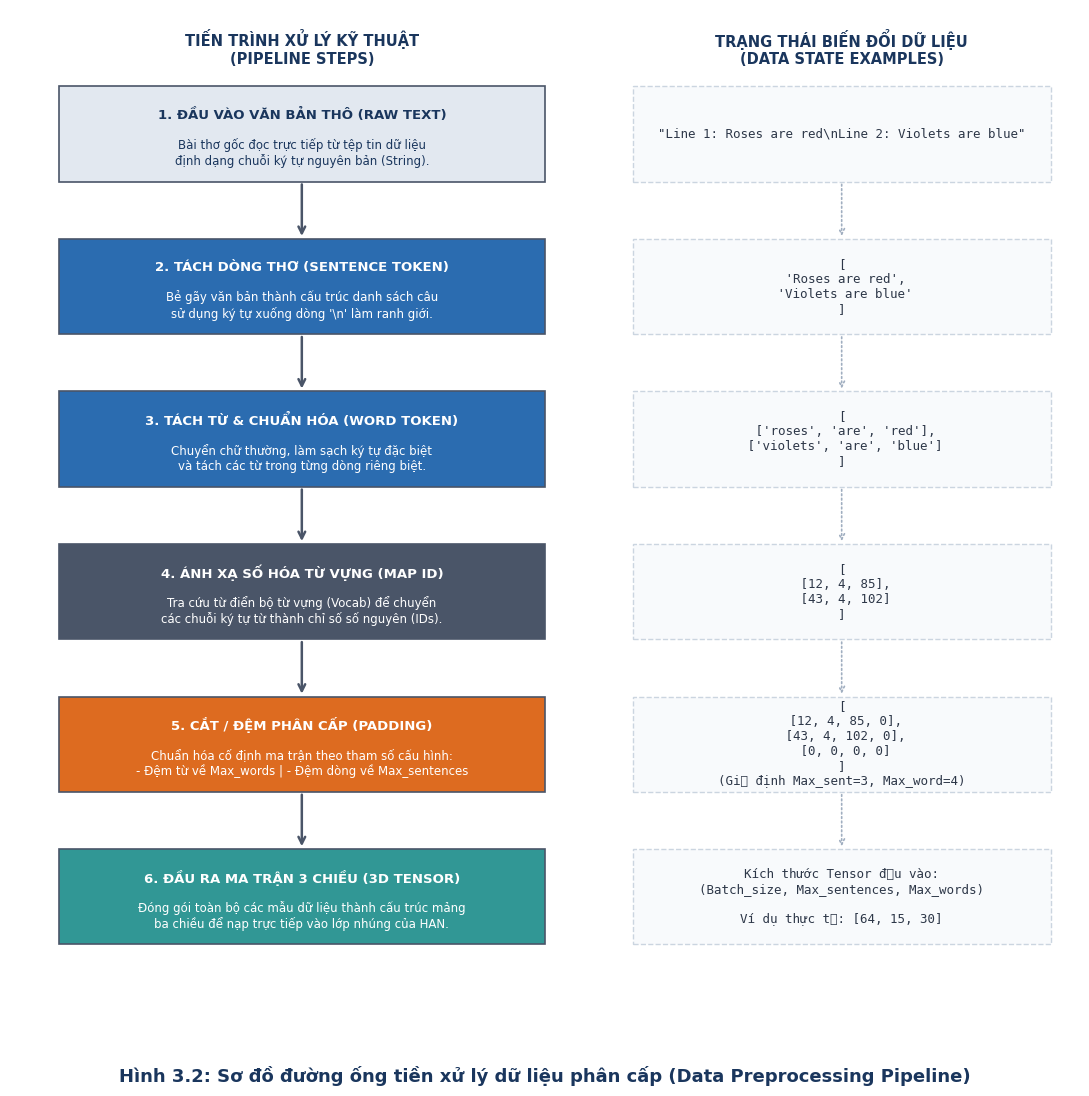

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Khởi tạo khung vẽ kích thước chuẩn bộ xử lý luồng pipeline
fig, ax = plt.subplots(figsize=(11, 11))
ax.set_xlim(0, 11)
ax.set_ylim(0, 11)
ax.axis('off')

# Cấu hình tiêu đề sơ đồ và các cột chức năng
font_title = {'family': 'sans-serif', 'color': '#1A365D', 'weight': 'bold', 'size': 13}

ax.text(3.0, 10.6, "TIẾN TRÌNH XỬ LÝ KỸ THUẬT\n(PIPELINE STEPS)", ha='center', va='center', weight='bold', color='#1A365D', fontsize=10.5)
ax.text(8.55, 10.6, "TRẠNG THÁI BIẾN ĐỔI DỮ LIỆU\n(DATA STATE EXAMPLES)", ha='center', va='center', weight='bold', color='#1A365D', fontsize=10.5)

# Hàm bổ trợ vẽ các cặp khối chức năng song song
def draw_pipeline_step(y, title, desc, example, bg_color, text_color='white'):
    # Khối bên trái: Mô tả kỹ thuật xử lý
    rect_process = patches.Rectangle((0.5, y), 5.0, 1.0, facecolor=bg_color, edgecolor='#4A5568', linewidth=1.2)
    ax.add_patch(rect_process)
    ax.text(3.0, y + 0.7, title, ha='center', va='center', color=text_color, weight='bold', fontsize=9.5)
    ax.text(3.0, y + 0.3, desc, ha='center', va='center', color=text_color, fontsize=8.5)

    # Khối bên phải: Trực quan hóa cấu trúc dữ liệu tương ứng
    rect_data = patches.Rectangle((6.4, y), 4.3, 1.0, facecolor='#F8FAFC', edgecolor='#CBD5E0', linewidth=1, linestyle='--')
    ax.add_patch(rect_data)
    ax.text(8.55, y + 0.5, example, ha='center', va='center', color='#2D3748', fontsize=9, family='monospace')

# --- ĐIỀN NỘI DUNG 6 BƯỚC CỦA ĐƯỜNG ỐNG TIỀN XỬ LÝ ---

draw_pipeline_step(
    y=9.2,
    title="1. ĐẦU VÀO VĂN BẢN THÔ (RAW TEXT)",
    desc="Bài thơ gốc đọc trực tiếp từ tệp tin dữ liệu\nđịnh dạng chuỗi ký tự nguyên bản (String).",
    example="\"Line 1: Roses are red\\nLine 2: Violets are blue\"",
    bg_color="#E2E8F0",
    text_color="#1A365D"
)

draw_pipeline_step(
    y=7.6,
    title="2. TÁCH DÒNG THƠ (SENTENCE TOKEN)",
    desc="Bẻ gãy văn bản thành cấu trúc danh sách câu\nsử dụng ký tự xuống dòng '\\n' làm ranh giới.",
    example="[\n 'Roses are red',\n 'Violets are blue'\n]",
    bg_color="#2B6CB0"
)

draw_pipeline_step(
    y=6.0,
    title="3. TÁCH TỪ & CHUẨN HÓA (WORD TOKEN)",
    desc="Chuyển chữ thường, làm sạch ký tự đặc biệt\nvà tách các từ trong từng dòng riêng biệt.",
    example="[\n ['roses', 'are', 'red'],\n ['violets', 'are', 'blue']\n]",
    bg_color="#2B6CB0"
)

draw_pipeline_step(
    y=4.4,
    title="4. ÁNH XẠ SỐ HÓA TỪ VỰNG (MAP ID)",
    desc="Tra cứu từ điển bộ từ vựng (Vocab) để chuyển\ncác chuỗi ký tự từ thành chỉ số số nguyên (IDs).",
    example="[\n [12, 4, 85],\n [43, 4, 102]\n]",
    bg_color="#4A5568"
)

draw_pipeline_step(
    y=2.8,
    title="5. CẮT / ĐỆM PHÂN CẤP (PADDING)",
    desc="Chuẩn hóa cố định ma trận theo tham số cấu hình:\n- Đệm từ về Max_words | - Đệm dòng về Max_sentences",
    example="[\n [12, 4, 85, 0],\n [43, 4, 102, 0],\n [0, 0, 0, 0]\n]\n(Giả định Max_sent=3, Max_word=4)",
    bg_color="#DD6B20"
)

draw_pipeline_step(
    y=1.2,
    title="6. ĐẦU RA MA TRẬN 3 CHIỀU (3D TENSOR)",
    desc="Đóng gói toàn bộ các mẫu dữ liệu thành cấu trúc mảng\nba chiều để nạp trực tiếp vào lớp nhúng của HAN.",
    example="Kích thước Tensor đầu vào:\n(Batch_size, Max_sentences, Max_words)\n\nVí dụ thực tế: [64, 15, 30]",
    bg_color="#319795"
)

# --- VẼ HỆ THỐNG MŨI TÊN CHỈ LUỒNG (CONNECTORS) ---
for i in range(5):
    y_top_box_bottom = 9.2 - i * 1.6
    y_bottom_box_top = y_top_box_bottom - 0.6

    # Mũi tên cột tiến trình (Mũi tên liền sắc nét)
    ax.annotate('', xy=(3.0, y_bottom_box_top), xytext=(3.0, y_top_box_bottom),
                arrowprops=dict(arrowstyle="->", color='#4A5568', lw=1.8, mutation_scale=12))

    # Mũi tên cột dữ liệu (Mũi tên chấm mảnh thể hiện trạng thái dịch chuyển)
    ax.annotate('', xy=(8.55, y_bottom_box_top), xytext=(8.55, y_top_box_bottom),
                arrowprops=dict(arrowstyle="->", color='#A0AEC0', lw=1.2, linestyle=':', mutation_scale=10))

# Thiết lập tên hình nằm dưới sơ đồ và lưu ảnh
plt.title("Hình 3.2: Sơ đồ đường ống tiền xử lý dữ liệu phân cấp (Data Preprocessing Pipeline)", y=-0.03, fontdict=font_title)
plt.tight_layout()
plt.savefig('hinh_3_2_duong_ong_tien_xu_ly.png', dpi=300, bbox_inches='tight')
plt.show()

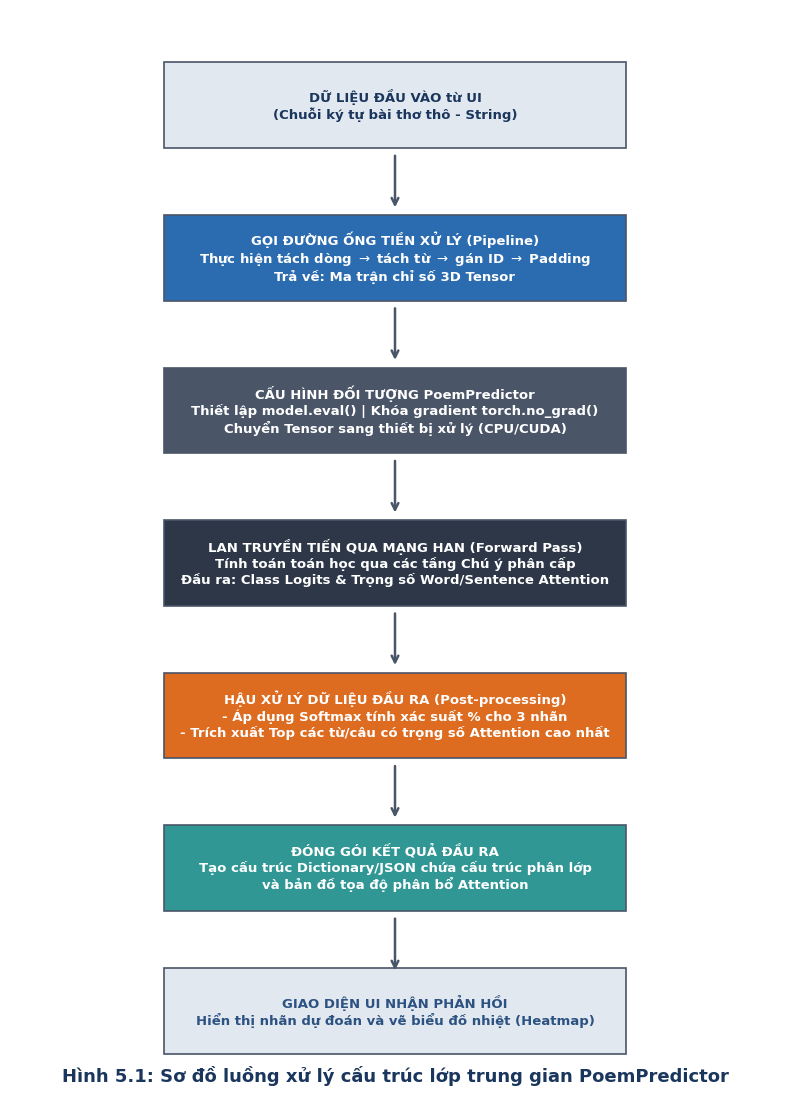

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Khởi tạo khung vẽ sơ đồ luồng dữ liệu (Flowchart)
fig, ax = plt.subplots(figsize=(8, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')

font_title = {'family': 'sans-serif', 'color': '#1A365D', 'weight': 'bold', 'size': 13}

# Hàm bổ trợ vẽ khối tiến trình
def draw_step_box(x, y, text, bg_color, text_color='white', width=6, height=0.9):
    rect = patches.Rectangle((x - width/2, y - height/2), width, height, facecolor=bg_color, edgecolor='#4A5568', lw=1.2)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', color=text_color, weight='bold', fontsize=9.5)

# Hàm bổ trợ vẽ mũi tên hướng xuống
def draw_down_arrow(x, y_top, y_bottom):
    ax.annotate('', xy=(x, y_bottom), xytext=(x, y_top),
                arrowprops=dict(arrowstyle="->", color='#4A5568', lw=1.8, mutation_scale=12))

# --- TIẾN HÀNH DỰNG LUỒNG XỬ LÝ (Từ trên xuống) ---

# 1. Khối Đầu vào
draw_step_box(5, 10.0, "DỮ LIỆU ĐẦU VÀO từ UI\n(Chuỗi ký tự bài thơ thô - String)", '#E2E8F0', '#1A365D')
draw_down_arrow(5, 9.5, 8.9)

# 2. Khối Gọi pipeline tiền xử lý
draw_step_box(5, 8.4, "GỌI ĐƯỜNG ỐNG TIỀN XỬ LÝ (Pipeline)\nThực hiện tách dòng $\\rightarrow$ tách từ $\\rightarrow$ gán ID $\\rightarrow$ Padding\nTrả về: Ma trận chỉ số 3D Tensor", '#2B6CB0')
draw_down_arrow(5, 7.9, 7.3)

# 3. Khối Chuyển trạng thái Mô hình
draw_step_box(5, 6.8, "CẤU HÌNH ĐỐI TƯỢNG PoemPredictor\nThiết lập model.eval() | Khóa gradient torch.no_grad()\nChuyển Tensor sang thiết bị xử lý (CPU/CUDA)", '#4A5568')
draw_down_arrow(5, 6.3, 5.7)

# 4. Khối Lan truyền tiến (Inference)
draw_step_box(5, 5.2, "LAN TRUYỀN TIẾN QUA MẠNG HAN (Forward Pass)\nTính toán toán học qua các tầng Chú ý phân cấp\nĐầu ra: Class Logits & Trọng số Word/Sentence Attention", '#2D3748')
draw_down_arrow(5, 4.7, 4.1)

# 5. Khối Hậu xử lý kết quả
draw_step_box(5, 3.6, "HẬU XỬ LÝ DỮ LIỆU ĐẦU RA (Post-processing)\n- Áp dụng Softmax tính xác suất % cho 3 nhãn\n- Trích xuất Top các từ/câu có trọng số Attention cao nhất", '#DD6B20')
draw_down_arrow(5, 3.1, 2.5)

# 6. Khối Đóng gói dữ liệu JSON
draw_step_box(5, 2.0, "ĐÓNG GÓI KẾT QUẢ ĐẦU RA\nTạo cấu trúc Dictionary/JSON chứa cấu trúc phân lớp\nvà bản đồ tọa độ phân bổ Attention", '#319795')
draw_down_arrow(5, 1.5, 0.9)

# 7. Khối Trả kết quả về giao diện UI
draw_step_box(5, 0.5, "GIAO DIỆN UI NHẬN PHẢN HỒI\nHiển thị nhãn dự đoán và vẽ biểu đồ nhiệt (Heatmap)", '#E2E8F0', '#2C5282')


# Đặt tên tiêu đề hình dưới sơ đồ
plt.title("Hình 5.1: Sơ đồ luồng xử lý cấu trúc lớp trung gian PoemPredictor", y=-0.03, fontdict=font_title)
plt.tight_layout()
plt.savefig('hinh_5_1_luong_predictor.png', dpi=300, bbox_inches='tight')
plt.show()

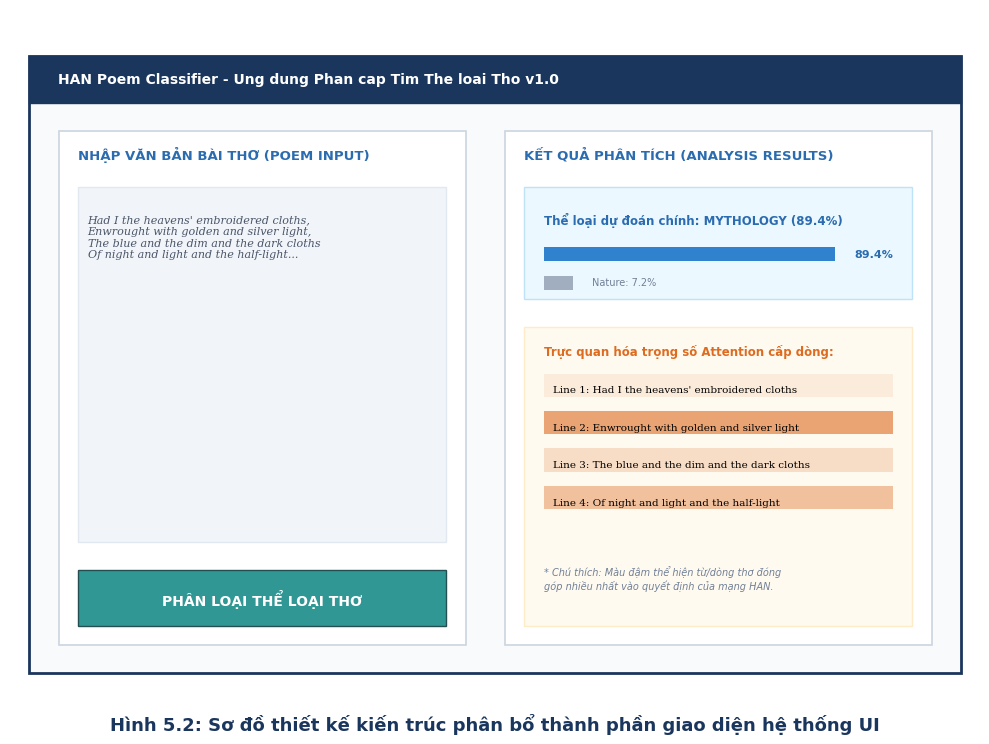

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Khởi tạo khung bản vẽ cấu trúc Dashboard UI
fig, ax = plt.subplots(figsize=(10, 7.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7.5)
ax.axis('off')

font_title = {'family': 'sans-serif', 'color': '#1A365D', 'weight': 'bold', 'size': 13}

# 1. Vẽ Khung cửa sổ chính của Ứng dụng (Main GUI Window)
main_window = patches.Rectangle((0.2, 0.4), 9.6, 6.6, facecolor='#F8FAFC', edgecolor='#1A365D', lw=2)
ax.add_patch(main_window)

# Thanh Tiêu đề ứng dụng (App Title Bar)
title_bar = patches.Rectangle((0.2, 6.5), 9.6, 0.5, facecolor='#1A365D', edgecolor='#1A365D')
ax.add_patch(title_bar)
# ĐÃ SỬA: Xóa emoji máy tính để tránh lỗi font chữ của hệ thống
ax.text(0.5, 6.75, "HAN Poem Classifier - Ung dung Phan cap Tim The loai Tho v1.0", color='white', weight='bold', va='center', fontsize=10)

# 2. PANEL BÊN TRÁI: Vùng nhập liệu của người dùng (User Input Panel)
left_panel = patches.Rectangle((0.5, 0.7), 4.2, 5.5, facecolor='white', edgecolor='#CBD5E0', lw=1.2)
ax.add_patch(left_panel)
ax.text(0.7, 5.9, "NHẬP VĂN BẢN BÀI THƠ (POEM INPUT)", color='#2B6CB0', weight='bold', fontsize=9.5)

# Hộp Textbox mô phỏng nhập thơ
input_box = patches.Rectangle((0.7, 1.8), 3.8, 3.8, facecolor='#F1F5F9', edgecolor='#E2E8F0', lw=1)
ax.add_patch(input_box)
poem_sample = "Had I the heavens' embroidered cloths,\nEnwrought with golden and silver light,\nThe blue and the dim and the dark cloths\nOf night and light and the half-light..."
ax.text(0.8, 5.3, poem_sample, va='top', ha='left', fontsize=8, color='#4A5568', style='italic', family='serif')

# Nút bấm kích hoạt dự đoán (Predict Button)
# ĐÃ SỬA: Xóa thuộc tính boxstyle gây lỗi tại đây
btn_predict = patches.Rectangle((0.7, 0.9), 3.8, 0.6, facecolor='#319795', edgecolor='#234E52', lw=1)
ax.add_patch(btn_predict)
# ĐÃ SỬA: Xóa biểu đồ emoji để không dính cảnh báo font
ax.text(2.6, 1.2, "PHÂN LOẠI THỂ LOẠI THƠ", color='white', weight='bold', ha='center', va='center', fontsize=10)


# 3. PANEL BÊN PHẢI: Kết quả phân tích từ mô hình HAN (Analysis Results Panel)
right_panel = patches.Rectangle((5.1, 0.7), 4.4, 5.5, facecolor='white', edgecolor='#CBD5E0', lw=1.2)
ax.add_patch(right_panel)
ax.text(5.3, 5.9, "KẾT QUẢ PHÂN TÍCH (ANALYSIS RESULTS)", color='#2B6CB0', weight='bold', fontsize=9.5)

# Vùng hiển thị phân bổ xác suất (Probabilities Block)
prob_box = patches.Rectangle((5.3, 4.4), 4.0, 1.2, facecolor='#EBF8FF', edgecolor='#BEE3F8', lw=1)
ax.add_patch(prob_box)
ax.text(5.5, 5.2, "Thể loại dự đoán chính: MYTHOLOGY (89.4%)", color='#2B6CB0', weight='bold', fontsize=8.5)
# Thanh biểu đồ mô phỏng phần trăm
ax.add_patch(patches.Rectangle((5.5, 4.8), 3.0, 0.15, facecolor='#3182CE'))
ax.text(8.7, 4.85, "89.4%", fontsize=8, weight='bold', color='#2B6CB0')
ax.add_patch(patches.Rectangle((5.5, 4.5), 0.3, 0.15, facecolor='#A0AEC0'))
ax.text(6.0, 4.55, "Nature: 7.2%", fontsize=7, color='#718096')

# Vùng mô phỏng bản đồ nhiệt Attention Heatmap (Attention Heatmap Simulator)
heatmap_box = patches.Rectangle((5.3, 0.9), 4.0, 3.2, facecolor='#FFFAF0', edgecolor='#FEEBC8', lw=1)
ax.add_patch(heatmap_box)
ax.text(5.5, 3.8, "Trực quan hóa trọng số Attention cấp dòng:", color='#DD6B20', weight='bold', fontsize=8.5)

# Mô phỏng các dòng chữ có highlight màu đậm nhạt theo Attention
def draw_heatmap_line(y, text, alpha_color):
    ax.add_patch(patches.Rectangle((5.5, y-0.05), 3.6, 0.25, facecolor='#DD6B20', alpha=alpha_color))
    ax.text(5.6, y, text, fontsize=7.5, family='serif', color='black')

draw_heatmap_line(3.4, "Line 1: Had I the heavens' embroidered cloths", 0.1)
draw_heatmap_line(3.0, "Line 2: Enwrought with golden and silver light", 0.6) # Trọng số cao, màu cam đậm
draw_heatmap_line(2.6, "Line 3: The blue and the dim and the dark cloths", 0.2)
draw_heatmap_line(2.2, "Line 4: Of night and light and the half-light", 0.4)

ax.text(5.5, 1.3, "* Chú thích: Màu đậm thể hiện từ/dòng thơ đóng\ngóp nhiều nhất vào quyết định của mạng HAN.", fontsize=7, color='#718096', style='italic')


# Thiết lập tiêu đề hình dưới sơ đồ
plt.title("Hình 5.2: Sơ đồ thiết kế kiến trúc phân bổ thành phần giao diện hệ thống UI", y=-0.04, fontdict=font_title)
plt.tight_layout()
plt.savefig('hinh_5_2_thiet_ke_giao_dien_ui.png', dpi=300, bbox_inches='tight')
plt.show()